In [150]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
pd.set_option('display.max_columns', None)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,doneDisconnectTimespan,connectionTimespan,doneChargingTimespan,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,2020-01-02 05:09:39-08:00,True,2020-01-02 12:51:54-08:00,0 days 01:39:40,0 days 06:02:21,0 days 04:22:41,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,2020-01-02 05:37:11-08:00,True,2020-01-02 15:31:50-08:00,0 days 02:20:16,0 days 09:01:31,0 days 06:41:15,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,2020-01-02 05:57:17-08:00,True,2020-01-02 06:56:35-08:00,0 days 08:04:16,0 days 10:42:47,0 days 02:38:31,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,2020-01-02 06:00:19-08:00,True,2020-01-02 07:04:58-08:00,0 days 01:19:54,0 days 02:38:41,0 days 01:18:47,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,2020-01-02 06:00:13-08:00,True,2020-01-02 14:24:01-08:00,0 days 03:51:10,0 days 08:08:39,0 days 04:17:29,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


<h3>Selection of features</h3> 
<p>Since the task is to find clusters for archtiypical charging sessions and not for how requests from registered users deviate from the actual charging session, we decided to only incorporate features that are not in the user inputs. Moreover, we calculated two measures from connectionTime, disconnectTime and doneChargingTime. The charging_duration is the timespan between connectionTime and doneChargingTime and the idle_time is the timespan from doneChargingTime to disconnectTime. With this calculation we decreased dimensionality from 4 to only 3 explainable features.</p>

In [152]:
# Calculate timespans
full_charging_df['session_duration'] = (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['charging_duration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
full_charging_df['idle_time'] = (full_charging_df['disconnectTime'] - full_charging_df['doneChargingTime']).dt.total_seconds() / 60

In [153]:
# calculate correlation value between charging duration and kwhDelievered
corr = full_charging_df['charging_duration'].corr(full_charging_df['kWhDelivered'])
print(f"Correlation between charging duration and kWhDelivered: {corr}")

KeyError: 'charging_duration'

In [129]:
# Select features for clustering
features = [
    'session_duration',
    'kWhDelivered',
]

In [130]:
# Drop rows with NaN values
X = full_charging_df[features].dropna()

# Compare sizes before and after dropping NaNs
print(full_charging_df[features].shape)
print(X.shape)
print(X.head())

(65037, 2)
(65037, 2)
   session_duration  kWhDelivered
0        362.350000        25.016
1        541.516667        33.097
2        642.783333         6.521
3        158.683333         2.355
4        488.650000        13.375


In [131]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
clustering_scaled = scaler.transform(X)
clustering_scaled_df = pd.DataFrame(clustering_scaled, columns=X.columns, index=X.index)
clustering_scaled_df.head()

,session_duration,kWhDelivered
0,-0.048296,1.292140
1,0.562441,2.078317
2,0.907635,-0.507186
3,-0.742547,-0.912484
4,0.382231,0.159620


In [132]:
from sklearn.cluster import KMeans

In [133]:
k_max = 15 # TODO: Are 15 enough?
clusters = []
losses = []

for k in range(k_max):
    model = KMeans(n_clusters=k+1, n_init='auto', random_state=42)
    model.fit(clustering_scaled_df)
    clusters.append(k+1)
    losses.append(model.inertia_)

(0.0, 14.0)

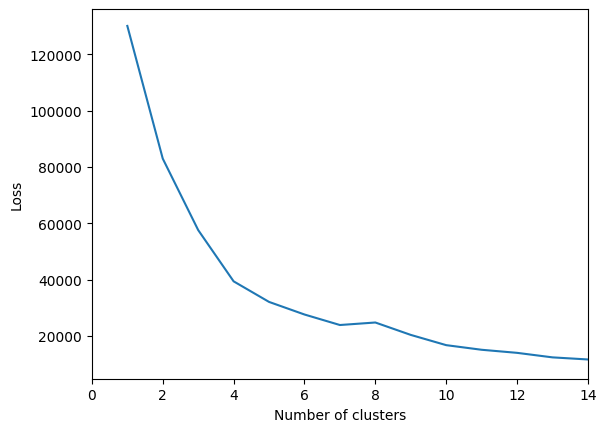

In [134]:
# Plot the loss curve to find the optimal number of clusters
plt.plot(clusters, losses)
plt.ylabel("Loss")
plt.xlabel("Number of clusters")
plt.xlim([0,14])

In [135]:
numbers = ["1", "2", "3", "4", "5", "6", "7"]

# refit algorithm
# seven_means = KMeans(n_clusters=7, n_init='auto')
# seven_means.fit(clustering_scaled_df)

# X["7 Clusters"] = seven_means.predict(clustering_scaled)
# X["7 Clusters"] = X["7 Clusters"].apply(lambda x: numbers[x])
# sns.pairplot(data=X, hue="7 Clusters")

/Users/dc/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-CRfD5Dnf-py3.11/lib/python3.11/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


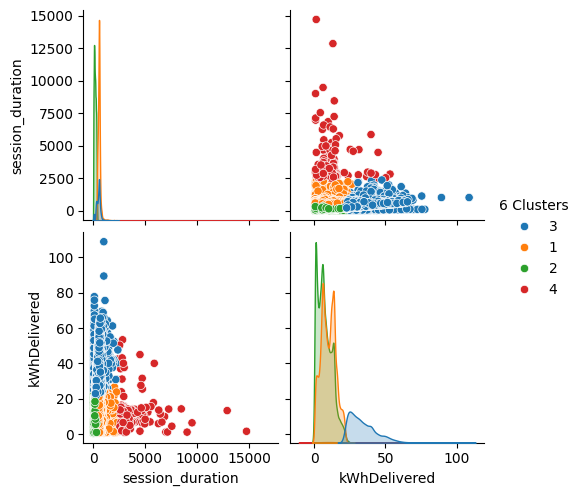

In [136]:
six_means = KMeans(n_clusters=4, n_init='auto', random_state=42)
# refit algorithm without column for 7 clusters
six_means.fit(clustering_scaled_df)
X["6 Clusters"] = six_means.predict(clustering_scaled)
X["6 Clusters"] = X["6 Clusters"].apply(lambda x: numbers[x])
sns.pairplot(data=X, hue="6 Clusters")

In [141]:
# Lenght of each cluster
X["6 Clusters"].value_counts()

6 Clusters
2    29619
1    27030
3     8260
4      128
Name: count, dtype: int64

In [140]:
cluster_stats = X.groupby("6 Clusters").agg(['min', 'max', 'median'])
print(cluster_stats)

           session_duration                            kWhDelivered  \
                        min           max       median          min   
6 Clusters                                                            
1                297.000000   2308.050000   548.608333        0.506   
2                  2.066667    402.216667   159.383333        0.501   
3                  2.550000   2368.700000   513.066667       21.145   
4               2331.633333  14716.150000  3581.041667        0.896   

                                 
                   max   median  
6 Clusters                       
1            26.513000   9.6305  
2            24.830000   6.3610  
3           108.797242  31.7545  
4            53.282000  11.2745  


In [145]:
# Min, max, median values of the kWhDelivered and session_duration for the whole dataset
print(X[['kWhDelivered', 'session_duration']].agg(['min', 'max', 'median']))

        kWhDelivered  session_duration
min         0.501000          2.066667
max       108.797242      14716.150000
median      9.099000        369.450000


<h4>Cluster Description</h4>
<p><b>Cluster 1: Medium Charge </b>-> Charging Events with a medium high session_duration and an average kWh_delivered</p>
<p><b>Cluster 2: Quick Session </b>-> Short charging time with relatively low energy consumption </p>
<p><b>Cluster 3: Power Charge </b>-> Use the highest amount of energy, but are connected within a regular session duration</p>
<p><b>Cluster 4: Long Idle </b>-> Stays connected for a long time, but doesn't charge the whole time</p>